# Aula 08 Hands-On — Tracking, Export, Quantização e Drift

## Contexto
Nesta prática final, tratamos o modelo como um artefato operacional, não apenas como resultado acadêmico. O fluxo vai da seleção do melhor candidato até uma verificação mínima de prontidão: rastreamento de runs, export para serving, quantização dinâmica, benchmark de latência e um monitor simples de drift.

## Objetivos de aprendizagem
- Registrar múltiplas execuções com parâmetros e métricas em um ledger local reproduzível.
- Selecionar um modelo candidato e comparar sua versão FP32, quantizada e exportada para ONNX.
- Medir acurácia, log loss, latência p50/p95 e tamanho do artefato.
- Simular um cenário de drift e construir um critério simples de alerta.

## Pergunta experimental e hipótese
**Pergunta:** depois de escolher um modelo, até que ponto export, quantização e drift alteram o comportamento observado offline?

**Hipótese:**
- Dois candidatos treinados com pequenas diferenças de capacidade devem apresentar trade-off entre qualidade e custo.
- A quantização dinâmica deve reduzir tamanho e latência com perda pequena de qualidade.
- Um conjunto deslocado por ruído e brilho deve elevar PSI e derrubar desempenho, justificando alerta de monitoramento.

## Setup, imports e semente de reprodutibilidade
O notebook usa apenas componentes locais. `MLflow`, `onnxruntime` e a cadeia completa de export ONNX são opcionais: se estiverem instalados, entram no fluxo; se não estiverem, o experimento continua funcional com ledger em `DataFrame`, quantização dinâmica e benchmark do modelo PyTorch local.

In [1]:
import json
import os
import random
import time
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

try:
    import onnxruntime as ort
    ONNXRUNTIME_AVAILABLE = True
except ImportError:
    ONNXRUNTIME_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ARTIFACT_DIR = Path('artifacts_mlops')
ARTIFACT_DIR.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
device, ONNXRUNTIME_AVAILABLE

('cuda', True)

## Carregamento do dataset e criação do conjunto com drift
Usamos novamente o dataset de dígitos porque ele permite treinar, exportar e medir inferência em segundos. O conjunto com drift é criado por ruído aditivo e aumento de brilho, simulando mudança de aquisição do dado.

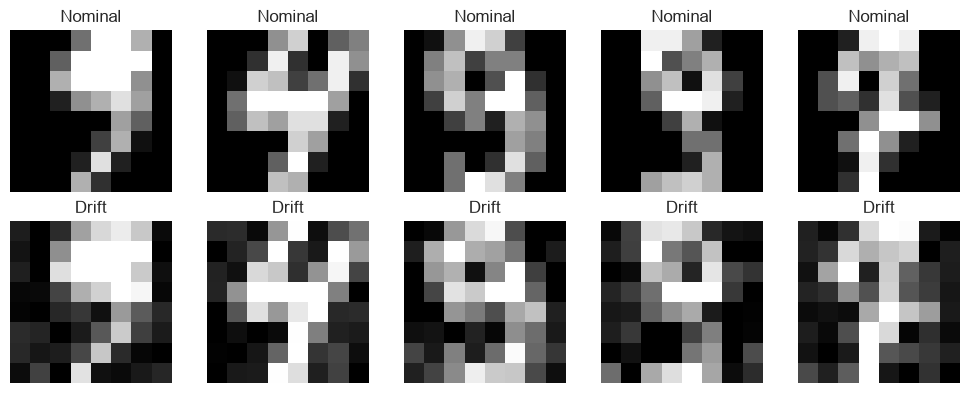

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

rng = np.random.default_rng(SEED)
X_test_drift = np.clip(X_test + rng.normal(0, 0.12, size=X_test.shape) + 0.08, 0.0, 1.0).astype(np.float32)

def make_loader(X_data, y_data, batch_size=128, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_data, dtype=torch.float32),
        torch.tensor(y_data, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)
drift_loader = make_loader(X_test_drift, y_test)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for col in range(5):
    axes[0, col].imshow(X_test[col].reshape(8, 8), cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title('Nominal')
    axes[1, col].imshow(X_test_drift[col].reshape(8, 8), cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title('Drift')
plt.tight_layout()

## Baseline e por que ele importa
O baseline operacional aqui é o melhor candidato em FP32 antes de qualquer compressão. Só depois dessa linha de base é que quantização, export e critérios de promoção fazem sentido. Comparar o modelo quantizado sem essa referência esconderia se a perda veio da compressão ou do treinamento.

In [3]:
candidate_specs = [
    {'name': 'mlp_small', 'hidden_dims': (64, 32), 'dropout': 0.1},
    {'name': 'mlp_large', 'hidden_dims': (128, 64), 'dropout': 0.15},
]
candidate_specs

[{'name': 'mlp_small', 'hidden_dims': (64, 32), 'dropout': 0.1},
 {'name': 'mlp_large', 'hidden_dims': (128, 64), 'dropout': 0.15}]

## Método principal
O método principal combina quatro peças: um classificador MLP pequeno, uma rotina de treino reproduzível, um ledger local de experimentos e funções de export/benchmark. O objetivo não é montar uma plataforma completa de MLOps, mas condensar o raciocínio operacional que antecede qualquer promoção de modelo.

In [4]:
class MLPClassifier(nn.Module):
    def __init__(self, hidden_dims=(64, 32), dropout=0.1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(64, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], 10),
        )

    def forward(self, x):
        return self.model(x)

class LocalExperimentTracker:
    def __init__(self):
        self.rows = []

    def log(self, run_name, params, metrics, artifacts):
        self.rows.append({
            'run_name': run_name,
            'params': json.dumps(params, ensure_ascii=False),
            'metrics': json.dumps(metrics, ensure_ascii=False),
            'artifacts': json.dumps(artifacts, ensure_ascii=False),
        })

    def to_frame(self):
        return pd.DataFrame(self.rows)

def evaluate_model(model, loader, criterion):
    model.eval()
    losses, probs_list, preds_list, targets_list = [], [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            losses.append(loss.item())
            probs_list.append(probs.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
            targets_list.append(yb.cpu().numpy())

    y_true = np.concatenate(targets_list)
    y_pred = np.concatenate(preds_list)
    y_prob = np.concatenate(probs_list)
    return {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(y_true, y_pred),
        'log_loss': log_loss(y_true, y_prob),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

def train_candidate(spec, epochs=20):
    model = MLPClassifier(hidden_dims=spec['hidden_dims'], dropout=spec['dropout']).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_state, best_val_loss = None, float('inf')

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        val_metrics = evaluate_model(model, val_loader, criterion)
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, criterion

def benchmark_callable(predict_fn, inputs, warmup=10, runs=80):
    for _ in range(warmup):
        _ = predict_fn(inputs)
    latencies = []
    for _ in range(runs):
        start = time.perf_counter()
        _ = predict_fn(inputs)
        latencies.append((time.perf_counter() - start) * 1000)
    return {
        'p50_ms': float(np.percentile(latencies, 50)),
        'p95_ms': float(np.percentile(latencies, 95)),
    }

def compute_psi(expected, actual, bins=10):
    quantiles = np.linspace(0, 1, bins + 1)
    breaks = np.quantile(expected, quantiles)
    breaks[0], breaks[-1] = -np.inf, np.inf
    exp_counts, _ = np.histogram(expected, bins=breaks)
    act_counts, _ = np.histogram(actual, bins=breaks)
    exp_ratio = np.clip(exp_counts / exp_counts.sum(), 1e-6, None)
    act_ratio = np.clip(act_counts / act_counts.sum(), 1e-6, None)
    return float(np.sum((act_ratio - exp_ratio) * np.log(act_ratio / exp_ratio)))

## Métricas e interpretação
Acurácia e `log loss` cobrem a qualidade do classificador. Latência p50 e p95 ajudam a separar comportamento típico de comportamento em cauda. O tamanho do artefato quantifica custo operacional. Para drift, usamos PSI sobre a confiança do modelo e a intensidade média do input: não é um diagnóstico completo, mas é um bom gatilho de triagem.

In [5]:
tracker = LocalExperimentTracker()
sample_batch = torch.tensor(X_test[:128], dtype=torch.float32).to(device)

## Execução do treinamento, seleção do candidato e avaliação operacional
Treinamos dois candidatos, registramos métricas e escolhemos o melhor por perda de validação e acurácia. Em seguida exportamos o melhor modelo para ONNX, criamos uma versão quantizada e medimos latência e qualidade nos conjuntos nominal e com drift. A célula exibe primeiro a tabela `candidate_df` (seleção, ordenada por `val_log_loss`) e, ao final, a `operational_df`.

In [6]:
candidate_results = []
trained_models = {}

for spec in candidate_specs:
    model, criterion = train_candidate(spec, epochs=20)
    val_metrics = evaluate_model(model, val_loader, criterion)
    test_metrics = evaluate_model(model, test_loader, criterion)
    model_path = ARTIFACT_DIR / f"{spec['name']}.pt"
    torch.save(model.state_dict(), model_path)

    tracker.log(
        run_name=spec['name'],
        params=spec,
        metrics={'val_accuracy': val_metrics['accuracy'], 'val_log_loss': val_metrics['log_loss'], 'test_accuracy': test_metrics['accuracy']},
        artifacts={'weights': str(model_path)},
    )

    candidate_results.append({
        'name': spec['name'],
        'val_accuracy': val_metrics['accuracy'],
        'val_log_loss': val_metrics['log_loss'],
        'test_accuracy': test_metrics['accuracy'],
        'test_log_loss': test_metrics['log_loss'],
    })
    trained_models[spec['name']] = (model, criterion, test_metrics)

candidate_df = pd.DataFrame(candidate_results).sort_values(['val_log_loss', 'val_accuracy'])
display(candidate_df)

best_name = candidate_df.iloc[0]['name']
best_model, criterion, nominal_metrics = trained_models[best_name]
best_model.eval()

onnx_path = ARTIFACT_DIR / f'{best_name}.onnx'
onnx_exported = False
onnx_export_error = None
try:
    torch.onnx.export(
        best_model.cpu(),
        torch.tensor(X_test[:1], dtype=torch.float32),
        onnx_path,
        input_names=['features'],
        output_names=['logits'],
        dynamic_axes={'features': {0: 'batch'}, 'logits': {0: 'batch'}},
        opset_version=17,
    )
    onnx_exported = True
except ModuleNotFoundError as exc:
    onnx_export_error = f'{type(exc).__name__}: {exc}'
best_model.to(device)

quantized_model = torch.quantization.quantize_dynamic(best_model.cpu(), {nn.Linear}, dtype=torch.qint8)
quantized_path = ARTIFACT_DIR / f'{best_name}_int8.pt'
torch.save(quantized_model.state_dict(), quantized_path)

def torch_predict(model, batch):
    model.eval()
    with torch.no_grad():
        return model(batch)

torch_latency = benchmark_callable(lambda batch: torch_predict(best_model.to(device), batch), sample_batch)
quant_latency = benchmark_callable(lambda batch: torch_predict(quantized_model, batch.cpu()), sample_batch.cpu())

if ONNXRUNTIME_AVAILABLE and onnx_exported:
    session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
    onnx_latency = benchmark_callable(
        lambda batch: session.run(None, {'features': batch.cpu().numpy().astype(np.float32)}),
        sample_batch.cpu(),
    )
else:
    onnx_latency = {'p50_ms': np.nan, 'p95_ms': np.nan}

def predict_quantized(model, X_data):
    with torch.no_grad():
        logits = model(torch.tensor(X_data, dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).numpy()
        preds = probs.argmax(axis=1)
    return preds, probs

quant_preds, quant_probs = predict_quantized(quantized_model, X_test)
operational_df = pd.DataFrame([
    {
        'variant': 'fp32_pytorch',
        'accuracy': nominal_metrics['accuracy'],
        'log_loss': nominal_metrics['log_loss'],
        'p50_ms': torch_latency['p50_ms'],
        'p95_ms': torch_latency['p95_ms'],
        'artifact_size_kb': os.path.getsize(ARTIFACT_DIR / f'{best_name}.pt') / 1024,
        'onnx_export_error': None,
    },
    {
        'variant': 'int8_dynamic',
        'accuracy': accuracy_score(y_test, quant_preds),
        'log_loss': log_loss(y_test, quant_probs),
        'p50_ms': quant_latency['p50_ms'],
        'p95_ms': quant_latency['p95_ms'],
        'artifact_size_kb': os.path.getsize(quantized_path) / 1024,
        'onnx_export_error': None,
    },
    {
        'variant': 'onnx_export',
        'accuracy': np.nan,
        'log_loss': np.nan,
        'p50_ms': onnx_latency['p50_ms'],
        'p95_ms': onnx_latency['p95_ms'],
        'artifact_size_kb': os.path.getsize(onnx_path) / 1024 if onnx_exported and onnx_path.exists() else np.nan,
        'onnx_export_error': onnx_export_error,
    },
])
operational_df

,name,val_accuracy,val_log_loss,test_accuracy,test_log_loss
1,mlp_large,0.941504,0.208777,0.947222,0.233288
0,mlp_small,0.891365,0.372516,0.875000,0.422246


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34136\19466733.py:38: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0911 05:29:49.090000 34136 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


W0911 05:29:49.670000 34136 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms


W0911 05:29:49.672000 34136 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align


W0911 05:29:49.674000 34136 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool


...

[torch.onnx] Obtain model graph for `MLPClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34136\19466733.py:52: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(best_model.cpu(), {nn.Linear}, dtype=torch.qint8)
C:\git\aula\.venv\Lib\site-packages\torch\ao\nn\quantized\modules\utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


,variant,accuracy,log_loss,p50_ms,p95_ms,artifact_size_kb,onnx_export_error
0,fp32_pytorch,0.947222,0.233288,0.39080,0.559945,70.356445,None
1,int8_dynamic,0.947222,0.233767,0.39680,0.567540,22.497070,None
2,onnx_export,NaN,NaN,0.09425,0.211865,1.646484,None


## Análise de erro, limitações e próximo experimento
Agora observamos o comportamento sob drift. A pergunta operacional é simples: a degradação foi grande o suficiente para bloquear promoção ou disparar monitoramento mais intensivo? Um PSI alto por si só não explica a causa, mas combinado com queda de acurácia já é sinal suficiente para investigar. As saídas abaixo trazem, nesta ordem, as métricas nominal × drift, a tabela `monitor_df` (PSI por sinal), o `gate_df` (critérios de release), o ledger de runs e as duas figuras.

Nominal: accuracy=0.9472 | log_loss=0.2333
Drift:   accuracy=0.9056 | log_loss=0.2748 | queda de acurácia=0.0417


,signal,psi
0,confidence_max,0.041016
1,pixel_intensity_mean,6.981836


,check,status
0,accuracy_nominal >= 0.94,True
1,quantized_drop <= 0.01,True
2,confidence_psi < 0.2,True
3,drift_accuracy_drop <= 0.08,True


,run_name,params,metrics,artifacts
0,mlp_small,"{""name"": ""mlp_small"", ""hidden_dims"": [64, 32],...","{""val_accuracy"": 0.8913649025069638, ""val_log_...","{""weights"": ""artifacts_mlops\\mlp_small.pt""}"
1,mlp_large,"{""name"": ""mlp_large"", ""hidden_dims"": [128, 64]...","{""val_accuracy"": 0.9415041782729805, ""val_log_...","{""weights"": ""artifacts_mlops\\mlp_large.pt""}"


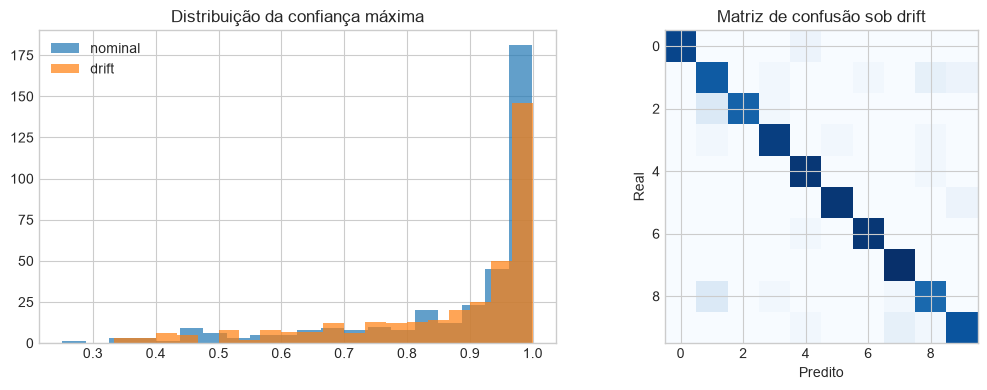

In [7]:
drift_metrics = evaluate_model(best_model.to(device), drift_loader, criterion)
print(f"Nominal: accuracy={nominal_metrics['accuracy']:.4f} | log_loss={nominal_metrics['log_loss']:.4f}")
print(f"Drift:   accuracy={drift_metrics['accuracy']:.4f} | log_loss={drift_metrics['log_loss']:.4f} | queda de acurácia={nominal_metrics['accuracy'] - drift_metrics['accuracy']:.4f}")
nominal_conf = nominal_metrics['y_prob'].max(axis=1)
drift_conf = drift_metrics['y_prob'].max(axis=1)
nominal_intensity = X_test.mean(axis=1)
drift_intensity = X_test_drift.mean(axis=1)

monitor_df = pd.DataFrame([
    {'signal': 'confidence_max', 'psi': compute_psi(nominal_conf, drift_conf)},
    {'signal': 'pixel_intensity_mean', 'psi': compute_psi(nominal_intensity, drift_intensity)},
])
display(monitor_df)

gate_df = pd.DataFrame([
    {'check': 'accuracy_nominal >= 0.94', 'status': nominal_metrics['accuracy'] >= 0.94},
    {'check': 'quantized_drop <= 0.01', 'status': (nominal_metrics['accuracy'] - accuracy_score(y_test, quant_preds)) <= 0.01},
    {'check': 'confidence_psi < 0.2', 'status': compute_psi(nominal_conf, drift_conf) < 0.2},
    {'check': 'drift_accuracy_drop <= 0.08', 'status': (nominal_metrics['accuracy'] - drift_metrics['accuracy']) <= 0.08},
])
display(gate_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(nominal_conf, bins=20, alpha=0.7, label='nominal')
axes[0].hist(drift_conf, bins=20, alpha=0.7, label='drift')
axes[0].set_title('Distribuição da confiança máxima')
axes[0].legend()

cm = confusion_matrix(drift_metrics['y_true'], drift_metrics['y_pred'])
axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('Matriz de confusão sob drift')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
plt.tight_layout()

tracker.to_frame()

## Fechamento e próximos passos
Se a hipótese estiver correta, a versão quantizada deve oferecer ganho operacional com perda pequena de qualidade, enquanto o conjunto com drift deve acionar pelo menos parte dos guardrails. Com isso, o curso fecha o ciclo completo: formular hipótese, treinar, avaliar, explicar, otimizar e preparar o modelo para operar sob monitoramento contínuo.